# Basic Random Forest Model Temperature Validation

This notebook validates temperatures predicted by the basic Random Forest model (5 features, no feature engineering) against Gaia GSP-Phot temperatures and examines the HR diagram to check for systematic biases.

**Goals:**
- Compare predicted temperature distribution with Gaia GSP-Phot temperatures
- Plot HR diagrams for both temperature sources
- Identify any systematic biases or discrepancies
- Analyze prediction quality for objects with/without ground truth

## Setup and Imports

Import required libraries and utilities from the project modules.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import utilities
from src.notebook_utils import (
    save_figure,
    MISSING_VALUE,
    RANDOM_STATE
)
from src.config import get_config

# Configuration
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

config = get_config()
print("✓ Setup complete")

✓ Setup complete


## Load Data

Load the predictions from the basic Random Forest model with Gaia GSP-Phot temperatures for comparison.

In [2]:
# Load basic model predictions
pred_file = config.get_path('processed') / 'eb_panstarrs_basic_model_predictions.parquet'
df = pd.read_parquet(pred_file)
print(f"Loaded {len(df):,} objects with basic model predictions")
print(f"Columns: {list(df.columns)}")

# Split into objects with/without ground truth
df_with_truth = df[df['teff_gspphot'].notna()].copy()
df_without_truth = df[df['teff_gspphot'].isna()].copy()

print(f"\nObjects with Gaia GSP-Phot ground truth: {len(df_with_truth):,} ({100*len(df_with_truth)/len(df):.1f}%)")
print(f"Objects without ground truth (new predictions): {len(df_without_truth):,} ({100*len(df_without_truth)/len(df):.1f}%)")

# Summary statistics
print("\n" + "="*60)
print("GAIA GSP-PHOT TEMPERATURES (Ground Truth)")
print("="*60)
print(f"Count: {df_with_truth['teff_gspphot'].notna().sum():,}")
print(f"Mean: {df_with_truth['teff_gspphot'].mean():.1f} K")
print(f"Median: {df_with_truth['teff_gspphot'].median():.1f} K")
print(f"Std: {df_with_truth['teff_gspphot'].std():.1f} K")
print(f"Range: {df_with_truth['teff_gspphot'].min():.1f} - {df_with_truth['teff_gspphot'].max():.1f} K")

print("\n" + "="*60)
print("BASIC MODEL PREDICTED TEMPERATURES (All Objects)")
print("="*60)
print(f"Count: {df['teff_predicted'].notna().sum():,}")
print(f"Mean: {df['teff_predicted'].mean():.1f} K")
print(f"Median: {df['teff_predicted'].median():.1f} K")
print(f"Std: {df['teff_predicted'].std():.1f} K")
print(f"Range: {df['teff_predicted'].min():.1f} - {df['teff_predicted'].max():.1f} K")

print("\n" + "="*60)
print("PREDICTION ERRORS (Objects with Ground Truth)")
print("="*60)
print(f"MAE: {df_with_truth['prediction_residual'].abs().mean():.1f} K")
print(f"Median AE: {df_with_truth['prediction_residual'].abs().median():.1f} K")
print(f"RMSE: {np.sqrt((df_with_truth['prediction_residual']**2).mean()):.1f} K")
print(f"Mean error %: {df_with_truth['prediction_error_percent'].mean():.2f}%")
print(f"Median error %: {df_with_truth['prediction_error_percent'].median():.2f}%")

df.head()

Loaded 1,123,615 objects with basic model predictions
Columns: ['original_ext_source_id', 'gaia_source_id', 'g_r_color', 'r_i_color', 'i_z_color', 'gPSFMag', 'teff_gspphot', 'Te_gr', 'Te_ri', 'Te_iz', 'B_V_color', 'teff_predicted', 'prediction_residual', 'prediction_error_percent']

Objects with Gaia GSP-Phot ground truth: 705,998 (62.8%)
Objects without ground truth (new predictions): 417,617 (37.2%)

GAIA GSP-PHOT TEMPERATURES (Ground Truth)
Count: 705,998
Mean: 5317.2 K
Median: 4967.0 K
Std: 1422.8 K
Range: 2737.3 - 31144.3 K

BASIC MODEL PREDICTED TEMPERATURES (All Objects)
Count: 1,123,615
Mean: 5009.2 K
Median: 4741.5 K
Std: 1084.3 K
Range: 3182.7 - 15597.3 K

PREDICTION ERRORS (Objects with Ground Truth)
MAE: 553.7 K
Median AE: 325.9 K
RMSE: 906.8 K
Mean error %: 9.58%
Median error %: 6.63%


,original_ext_source_id,gaia_source_id,g_r_color,r_i_color,i_z_color,gPSFMag,teff_gspphot,Te_gr,Te_ri,Te_iz,B_V_color,teff_predicted,prediction_residual,prediction_error_percent
0,108690456271144410,46626164993792,0.432299,0.170500,0.038700,20.382799,NaN,5729.909939,5260.390367,5598.938292,0.643653,5125.617205,NaN,NaN
1,109270450082003814,138577120584320,0.357201,0.074599,0.171000,15.891400,6317.194336,5965.409526,5850.695406,4685.570589,0.570057,6995.354747,-678.160411,10.735152
2,109030455555466575,160219460292352,0.554600,0.332001,0.097198,18.137400,4596.814453,5383.780145,4496.399916,5154.649759,0.763508,5095.273907,-498.459454,10.843584
3,109510460340003115,203551385701760,0.818900,0.160200,0.381200,14.457200,4162.139160,4762.112580,5318.016770,3721.113012,1.022522,6479.090746,-2316.951586,55.667326
4,109990456293919491,278760557996032,0.091299,-0.014299,-0.005001,18.145599,6881.932129,6981.365902,6529.967395,5984.262034,0.309473,6970.730164,-88.798035,1.290307


## Temperature Distribution Comparison

Compare the distributions of Gaia GSP-Phot temperatures vs. basic model predicted temperatures to check for systematic differences or biases.

✓ Saved figure: reports/figures/validation/basic_model_temperature_distribution_comparison.png


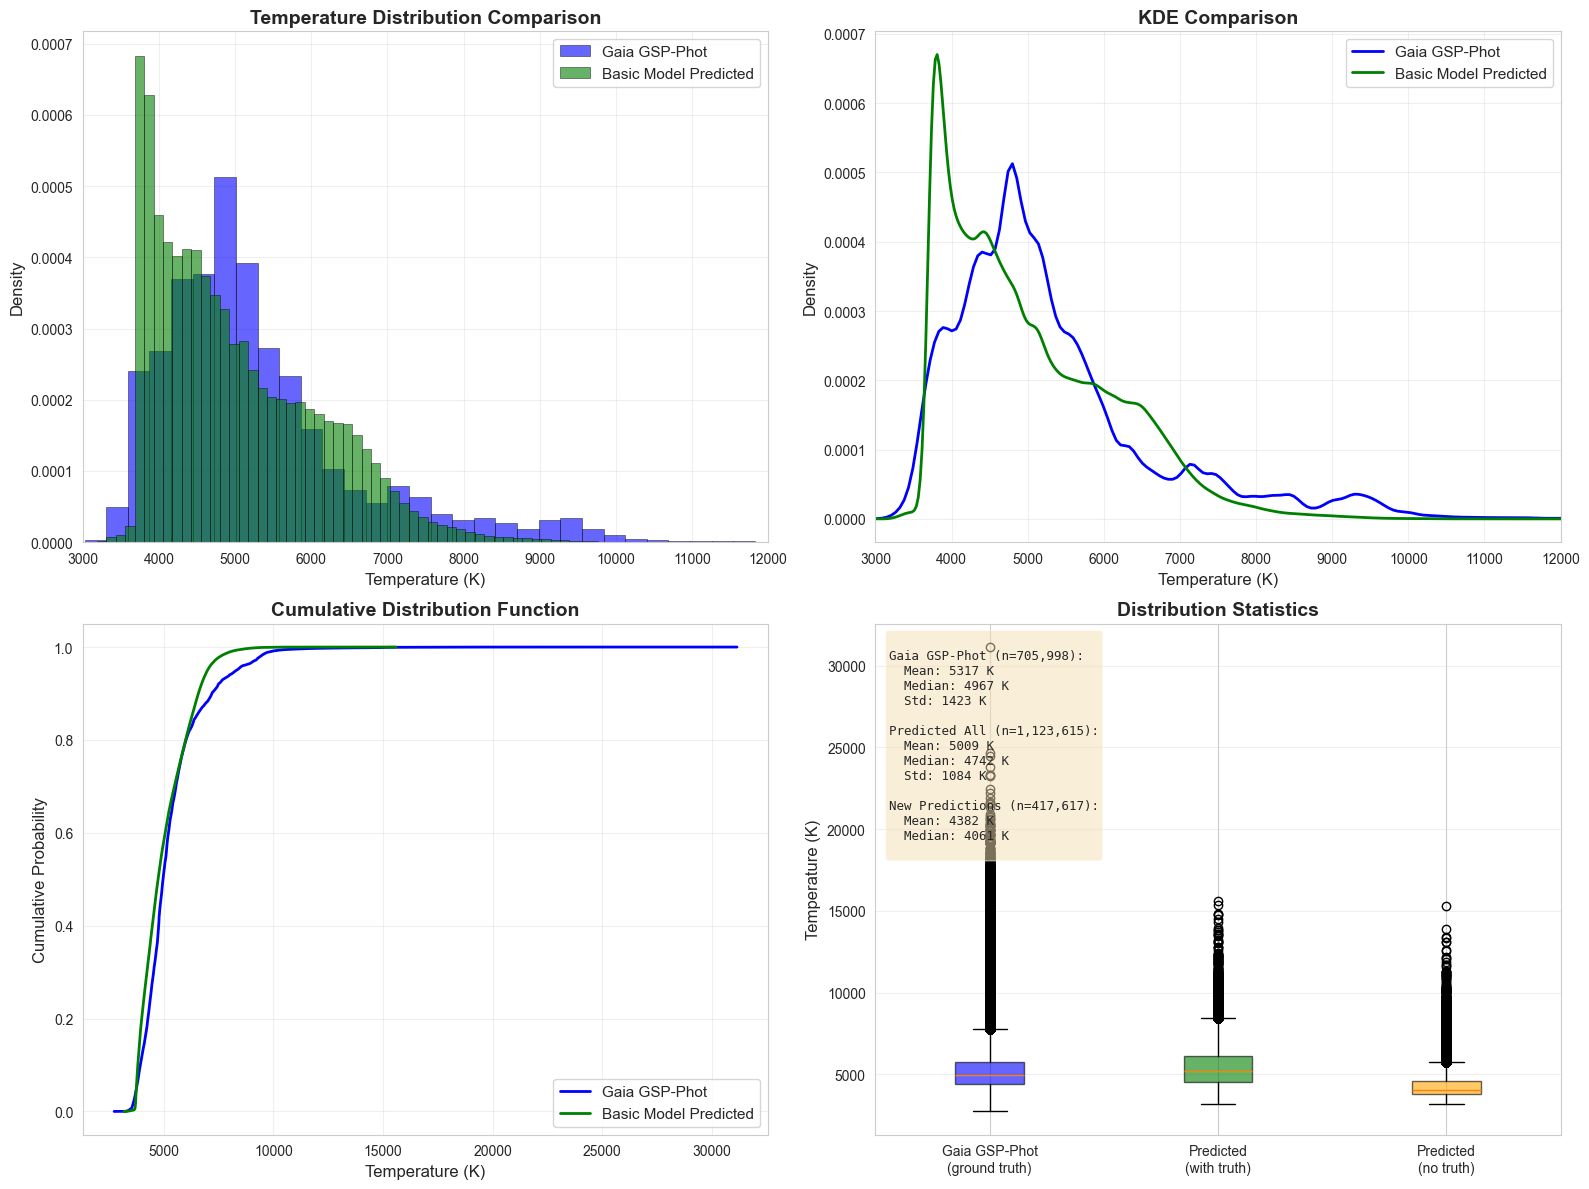

✓ Distribution comparison complete


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overlaid histograms
ax1 = axes[0, 0]
ax1.hist(df_with_truth['teff_gspphot'].dropna(), bins=100, alpha=0.6, label='Gaia GSP-Phot', 
         color='blue', density=True, edgecolor='black', linewidth=0.5)
ax1.hist(df['teff_predicted'].dropna(), bins=100, alpha=0.6, label='Basic Model Predicted', 
         color='green', density=True, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Temperature (K)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Temperature Distribution Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_xlim(3000, 12000)

# 2. KDE plots
ax2 = axes[0, 1]
df_with_truth['teff_gspphot'].dropna().plot.kde(ax=ax2, label='Gaia GSP-Phot', 
                                             color='blue', linewidth=2)
df['teff_predicted'].dropna().plot.kde(ax=ax2, label='Basic Model Predicted', 
                                               color='green', linewidth=2)
ax2.set_xlabel('Temperature (K)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('KDE Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xlim(3000, 12000)

# 3. Cumulative distribution
ax3 = axes[1, 0]
gaia_sorted = np.sort(df_with_truth['teff_gspphot'].dropna())
pred_sorted = np.sort(df['teff_predicted'].dropna())
ax3.plot(gaia_sorted, np.linspace(0, 1, len(gaia_sorted)), label='Gaia GSP-Phot', 
         color='blue', linewidth=2)
ax3.plot(pred_sorted, np.linspace(0, 1, len(pred_sorted)), label='Basic Model Predicted', 
         color='green', linewidth=2)
ax3.set_xlabel('Temperature (K)', fontsize=12)
ax3.set_ylabel('Cumulative Probability', fontsize=12)
ax3.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(alpha=0.3)

# 4. Box plots
ax4 = axes[1, 1]
box_data = [
    df_with_truth['teff_gspphot'].dropna(), 
    df_with_truth['teff_predicted'].dropna(),
    df_without_truth['teff_predicted'].dropna()
]
bp = ax4.boxplot(box_data, tick_labels=['Gaia GSP-Phot\n(ground truth)', 'Predicted\n(with truth)', 'Predicted\n(no truth)'], 
                 patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('green')
bp['boxes'][1].set_alpha(0.6)
bp['boxes'][2].set_facecolor('orange')
bp['boxes'][2].set_alpha(0.6)
ax4.set_ylabel('Temperature (K)', fontsize=12)
ax4.set_title('Distribution Statistics', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')
ax4.tick_params(axis='x', rotation=0)

# Add statistics text
stats_text = f"""
Gaia GSP-Phot (n={len(df_with_truth):,}):
  Mean: {df_with_truth['teff_gspphot'].mean():.0f} K
  Median: {df_with_truth['teff_gspphot'].median():.0f} K
  Std: {df_with_truth['teff_gspphot'].std():.0f} K

Predicted All (n={len(df):,}):
  Mean: {df['teff_predicted'].mean():.0f} K
  Median: {df['teff_predicted'].median():.0f} K
  Std: {df['teff_predicted'].std():.0f} K

New Predictions (n={len(df_without_truth):,}):
  Mean: {df_without_truth['teff_predicted'].mean():.0f} K
  Median: {df_without_truth['teff_predicted'].median():.0f} K
"""
ax4.text(0.02, 0.98, stats_text, transform=ax4.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
save_figure(fig, 'basic_model_temperature_distribution_comparison.png', subdir='validation')
plt.show()

print("✓ Distribution comparison complete")

## Prediction Residual Analysis

Analyze the prediction residuals (Gaia - Predicted) to identify systematic biases as a function of temperature, color, and magnitude.

✓ Saved figure: reports/figures/validation/basic_model_residual_analysis.png


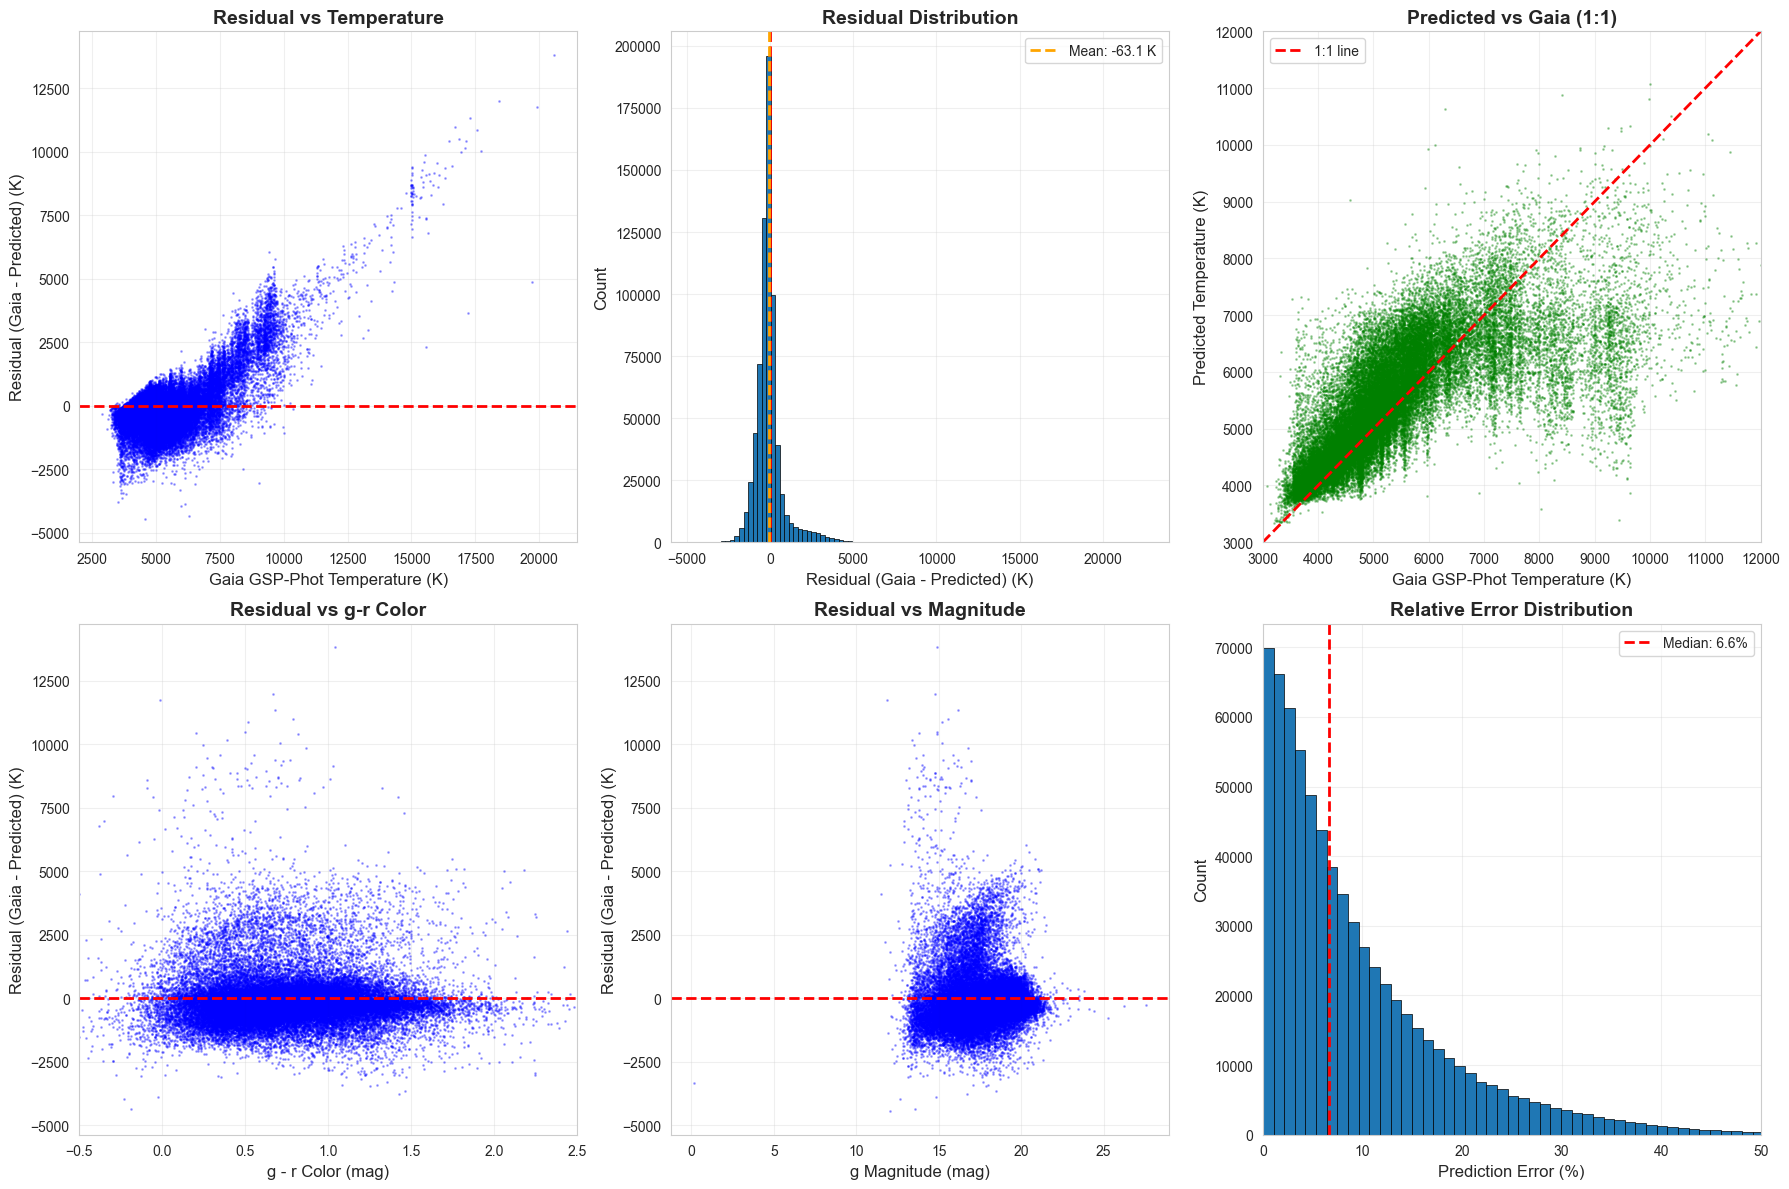

✓ Residual analysis complete


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Sample for faster plotting
sample_size = 50000
df_sample = df_with_truth.sample(n=min(sample_size, len(df_with_truth)), random_state=RANDOM_STATE)

# 1. Residual vs Gaia temperature
ax1 = axes[0, 0]
ax1.scatter(df_sample['teff_gspphot'], df_sample['prediction_residual'], 
            s=1, alpha=0.3, color='blue')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Gaia GSP-Phot Temperature (K)', fontsize=12)
ax1.set_ylabel('Residual (Gaia - Predicted) (K)', fontsize=12)
ax1.set_title('Residual vs Temperature', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# 2. Residual distribution
ax2 = axes[0, 1]
ax2.hist(df_with_truth['prediction_residual'], bins=100, edgecolor='black', linewidth=0.5)
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.axvline(df_with_truth['prediction_residual'].mean(), color='orange', linestyle='--', 
            linewidth=2, label=f'Mean: {df_with_truth["prediction_residual"].mean():.1f} K')
ax2.set_xlabel('Residual (Gaia - Predicted) (K)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Residual Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 3. Predicted vs Gaia (1:1 plot)
ax3 = axes[0, 2]
ax3.scatter(df_sample['teff_gspphot'], df_sample['teff_predicted'], 
            s=1, alpha=0.3, color='green')
ax3.plot([3000, 12000], [3000, 12000], 'r--', linewidth=2, label='1:1 line')
ax3.set_xlabel('Gaia GSP-Phot Temperature (K)', fontsize=12)
ax3.set_ylabel('Predicted Temperature (K)', fontsize=12)
ax3.set_title('Predicted vs Gaia (1:1)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)
ax3.set_xlim(3000, 12000)
ax3.set_ylim(3000, 12000)

# 4. Residual vs g-r color
ax4 = axes[1, 0]
ax4.scatter(df_sample['g_r_color'], df_sample['prediction_residual'], 
            s=1, alpha=0.3, color='blue')
ax4.axhline(0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('g - r Color (mag)', fontsize=12)
ax4.set_ylabel('Residual (Gaia - Predicted) (K)', fontsize=12)
ax4.set_title('Residual vs g-r Color', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.set_xlim(-0.5, 2.5)

# 5. Residual vs g magnitude
ax5 = axes[1, 1]
ax5.scatter(df_sample['gPSFMag'], df_sample['prediction_residual'], 
            s=1, alpha=0.3, color='blue')
ax5.axhline(0, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('g Magnitude (mag)', fontsize=12)
ax5.set_ylabel('Residual (Gaia - Predicted) (K)', fontsize=12)
ax5.set_title('Residual vs Magnitude', fontsize=14, fontweight='bold')
ax5.grid(alpha=0.3)

# 6. Relative error distribution
ax6 = axes[1, 2]
ax6.hist(df_with_truth['prediction_error_percent'], bins=100, edgecolor='black', linewidth=0.5)
ax6.axvline(df_with_truth['prediction_error_percent'].median(), color='red', linestyle='--', 
            linewidth=2, label=f'Median: {df_with_truth["prediction_error_percent"].median():.1f}%')
ax6.set_xlabel('Prediction Error (%)', fontsize=12)
ax6.set_ylabel('Count', fontsize=12)
ax6.set_title('Relative Error Distribution', fontsize=14, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(alpha=0.3)
ax6.set_xlim(0, 50)

plt.tight_layout()
save_figure(fig, 'basic_model_residual_analysis.png', subdir='validation')
plt.show()

print("✓ Residual analysis complete")

## HR Diagram Comparison

Compare HR diagrams for both datasets to identify any systematic biases or differences in the distribution of stars in color-magnitude space.

✓ Saved figure: reports/figures/validation/basic_model_hr_diagram_comparison.png


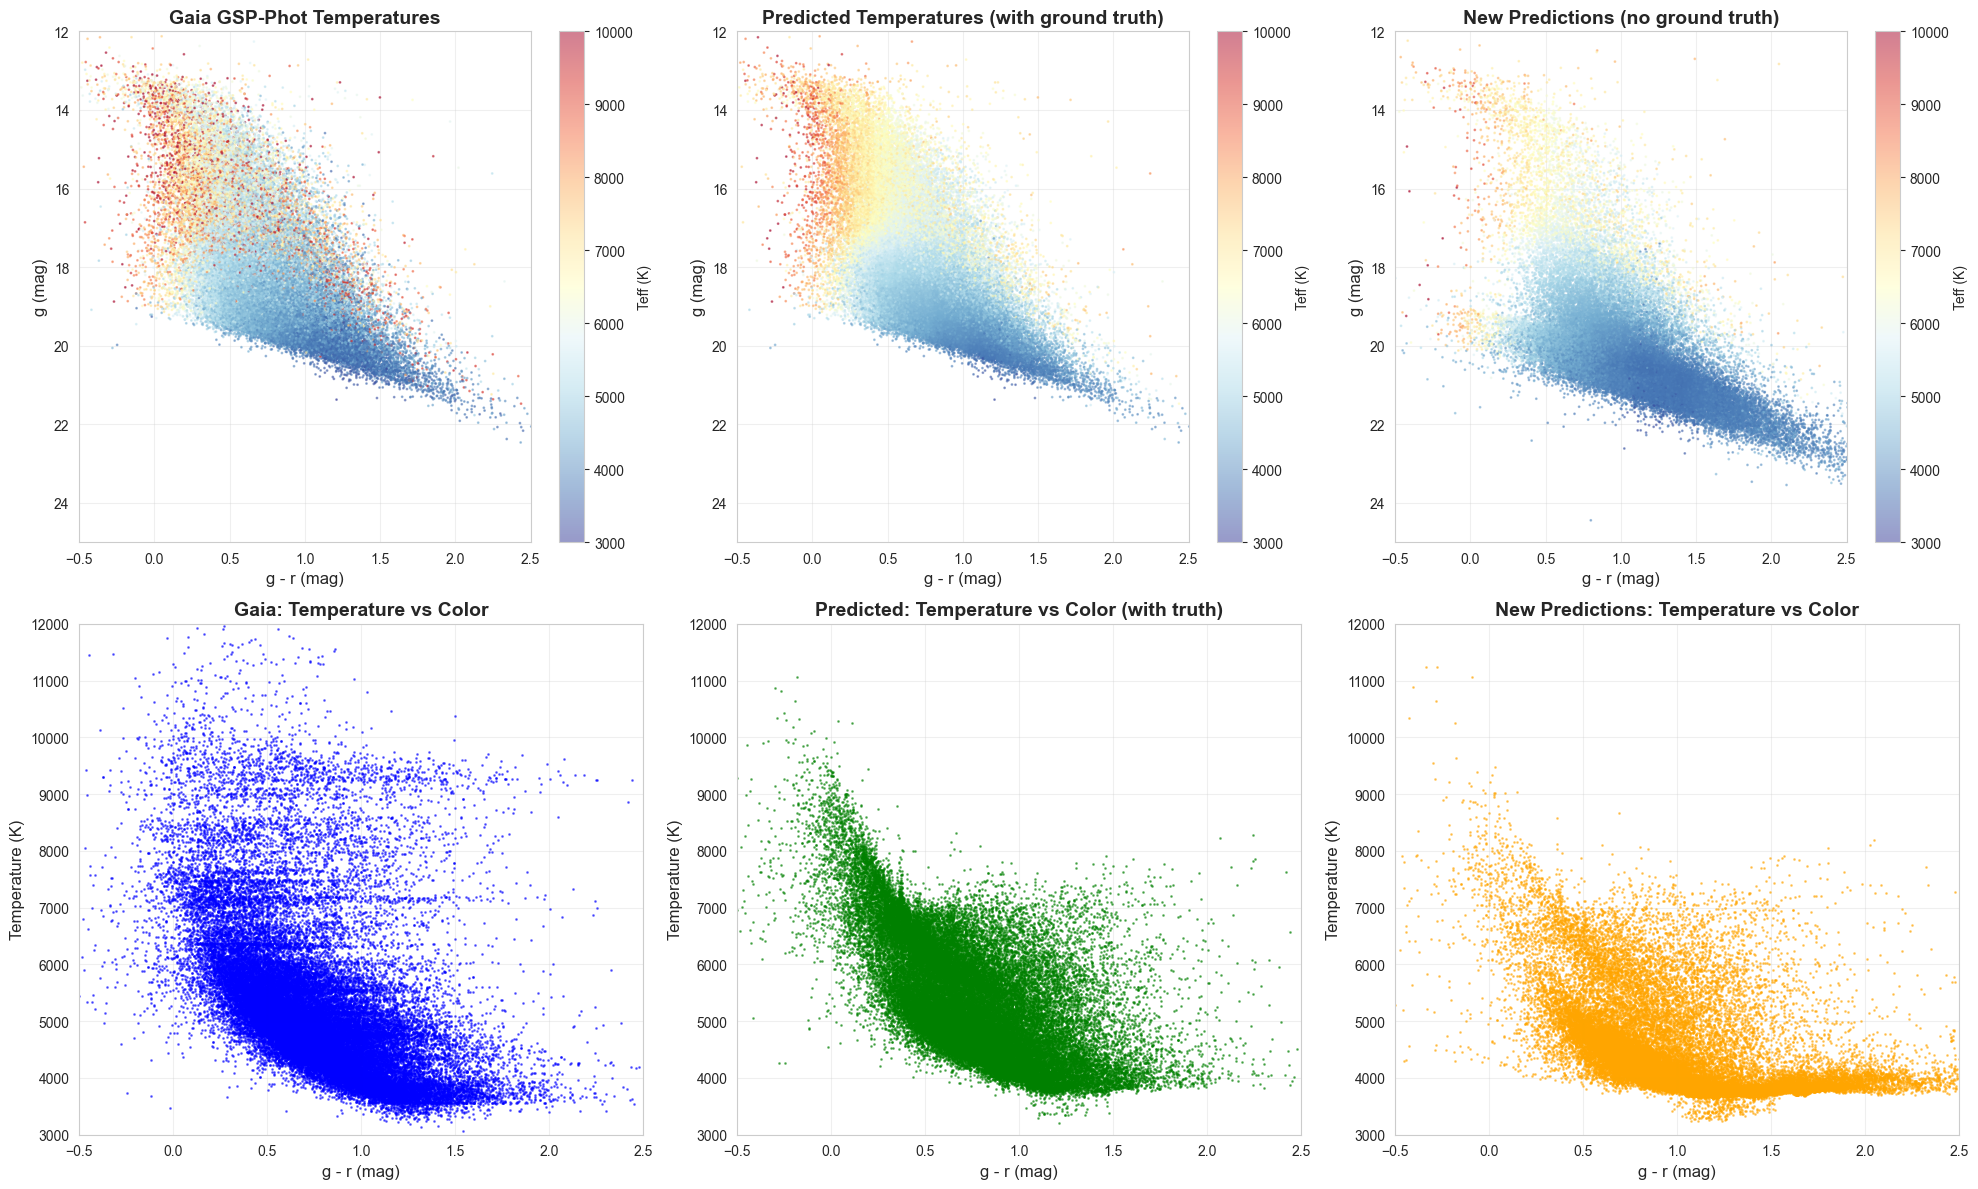

✓ HR diagram comparison complete


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Sample data for plotting (to avoid overplotting)
sample_size = 50000
truth_sample = df_with_truth.sample(n=min(sample_size, len(df_with_truth)), random_state=RANDOM_STATE)
new_sample = df_without_truth.sample(n=min(sample_size, len(df_without_truth)), random_state=RANDOM_STATE)
all_sample = df.sample(n=min(sample_size, len(df)), random_state=RANDOM_STATE)

# 1. Gaia GSP-Phot: g-r vs g magnitude, colored by temperature
ax1 = axes[0, 0]
scatter1 = ax1.scatter(truth_sample['g_r_color'], truth_sample['gPSFMag'], 
                       c=truth_sample['teff_gspphot'], cmap='RdYlBu_r', 
                       s=1, alpha=0.5, vmin=3000, vmax=10000)
ax1.set_xlabel('g - r (mag)', fontsize=12)
ax1.set_ylabel('g (mag)', fontsize=12)
ax1.set_title('Gaia GSP-Phot Temperatures', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.set_xlim(-0.5, 2.5)
ax1.set_ylim(25, 12)  # Set equal ylim from 12 to 25 (inverted axis)
ax1.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Teff (K)')

# 2. Predicted: g-r vs g magnitude, colored by temperature (objects with ground truth)
ax2 = axes[0, 1]
scatter2 = ax2.scatter(truth_sample['g_r_color'], truth_sample['gPSFMag'], 
                       c=truth_sample['teff_predicted'], cmap='RdYlBu_r', 
                       s=1, alpha=0.5, vmin=3000, vmax=10000)
ax2.set_xlabel('g - r (mag)', fontsize=12)
ax2.set_ylabel('g (mag)', fontsize=12)
ax2.set_title('Predicted Temperatures (with ground truth)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(25, 12)  # Set equal ylim from 12 to 25 (inverted axis)
ax2.grid(alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Teff (K)')

# 3. New predictions: g-r vs g magnitude, colored by temperature
ax3 = axes[0, 2]
scatter3 = ax3.scatter(new_sample['g_r_color'], new_sample['gPSFMag'], 
                       c=new_sample['teff_predicted'], cmap='RdYlBu_r', 
                       s=1, alpha=0.5, vmin=3000, vmax=10000)
ax3.set_xlabel('g - r (mag)', fontsize=12)
ax3.set_ylabel('g (mag)', fontsize=12)
ax3.set_title('New Predictions (no ground truth)', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
ax3.set_xlim(-0.5, 2.5)
ax3.set_ylim(25, 12)  # Set equal ylim from 12 to 25 (inverted axis)
ax3.grid(alpha=0.3)
plt.colorbar(scatter3, ax=ax3, label='Teff (K)')

# 4. Temperature vs g-r color (Gaia)
ax4 = axes[1, 0]
ax4.scatter(truth_sample['g_r_color'], truth_sample['teff_gspphot'], 
            s=1, alpha=0.5, color='blue')
ax4.set_xlabel('g - r (mag)', fontsize=12)
ax4.set_ylabel('Temperature (K)', fontsize=12)
ax4.set_title('Gaia: Temperature vs Color', fontsize=14, fontweight='bold')
ax4.set_xlim(-0.5, 2.5)
ax4.set_ylim(3000, 12000)
ax4.grid(alpha=0.3)

# 5. Temperature vs g-r color (Predicted - with truth)
ax5 = axes[1, 1]
ax5.scatter(truth_sample['g_r_color'], truth_sample['teff_predicted'], 
            s=1, alpha=0.5, color='green')
ax5.set_xlabel('g - r (mag)', fontsize=12)
ax5.set_ylabel('Temperature (K)', fontsize=12)
ax5.set_title('Predicted: Temperature vs Color (with truth)', fontsize=14, fontweight='bold')
ax5.set_xlim(-0.5, 2.5)
ax5.set_ylim(3000, 12000)
ax5.grid(alpha=0.3)

# 6. Temperature vs g-r color (New predictions)
ax6 = axes[1, 2]
ax6.scatter(new_sample['g_r_color'], new_sample['teff_predicted'], 
            s=1, alpha=0.5, color='orange')
ax6.set_xlabel('g - r (mag)', fontsize=12)
ax6.set_ylabel('Temperature (K)', fontsize=12)
ax6.set_title('New Predictions: Temperature vs Color', fontsize=14, fontweight='bold')
ax6.set_xlim(-0.5, 2.5)
ax6.set_ylim(3000, 12000)
ax6.grid(alpha=0.3)

plt.tight_layout()
save_figure(fig, 'basic_model_hr_diagram_comparison.png', subdir='validation')
plt.show()

print("✓ HR diagram comparison complete")

## Model Performance by Temperature Range

Analyze how the model performance varies across different temperature ranges.

/var/folders/dh/bbtpjwmd2sx_tz124bn85xrr0000gn/T/ipykernel_19833/678457510.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_with_truth.groupby('temp_bin').agg({



MODEL PERFORMANCE BY TEMPERATURE RANGE
                 Count  Mean Residual (K)  Std Residual (K)  Median |Residual| (K)  Mean Error %  Median Error %
temp_bin                                                                                                        
(3000, 3500]      4201             -480.2             386.1                  402.8          14.1            11.8
(3500, 4000]     79082             -398.3             416.2                  287.3          10.7             7.6
(4000, 4500]    118842             -272.0             410.1                  202.2           7.6             4.7
(4500, 5000]    160457             -226.9             491.6                  236.1           7.8             5.0
(5000, 5500]    118894             -278.5             529.3                  319.6           8.5             6.1
(5500, 6000]     80698             -331.1             552.7                  443.7           9.0             7.7
(6000, 6500]     39496             -209.5             54

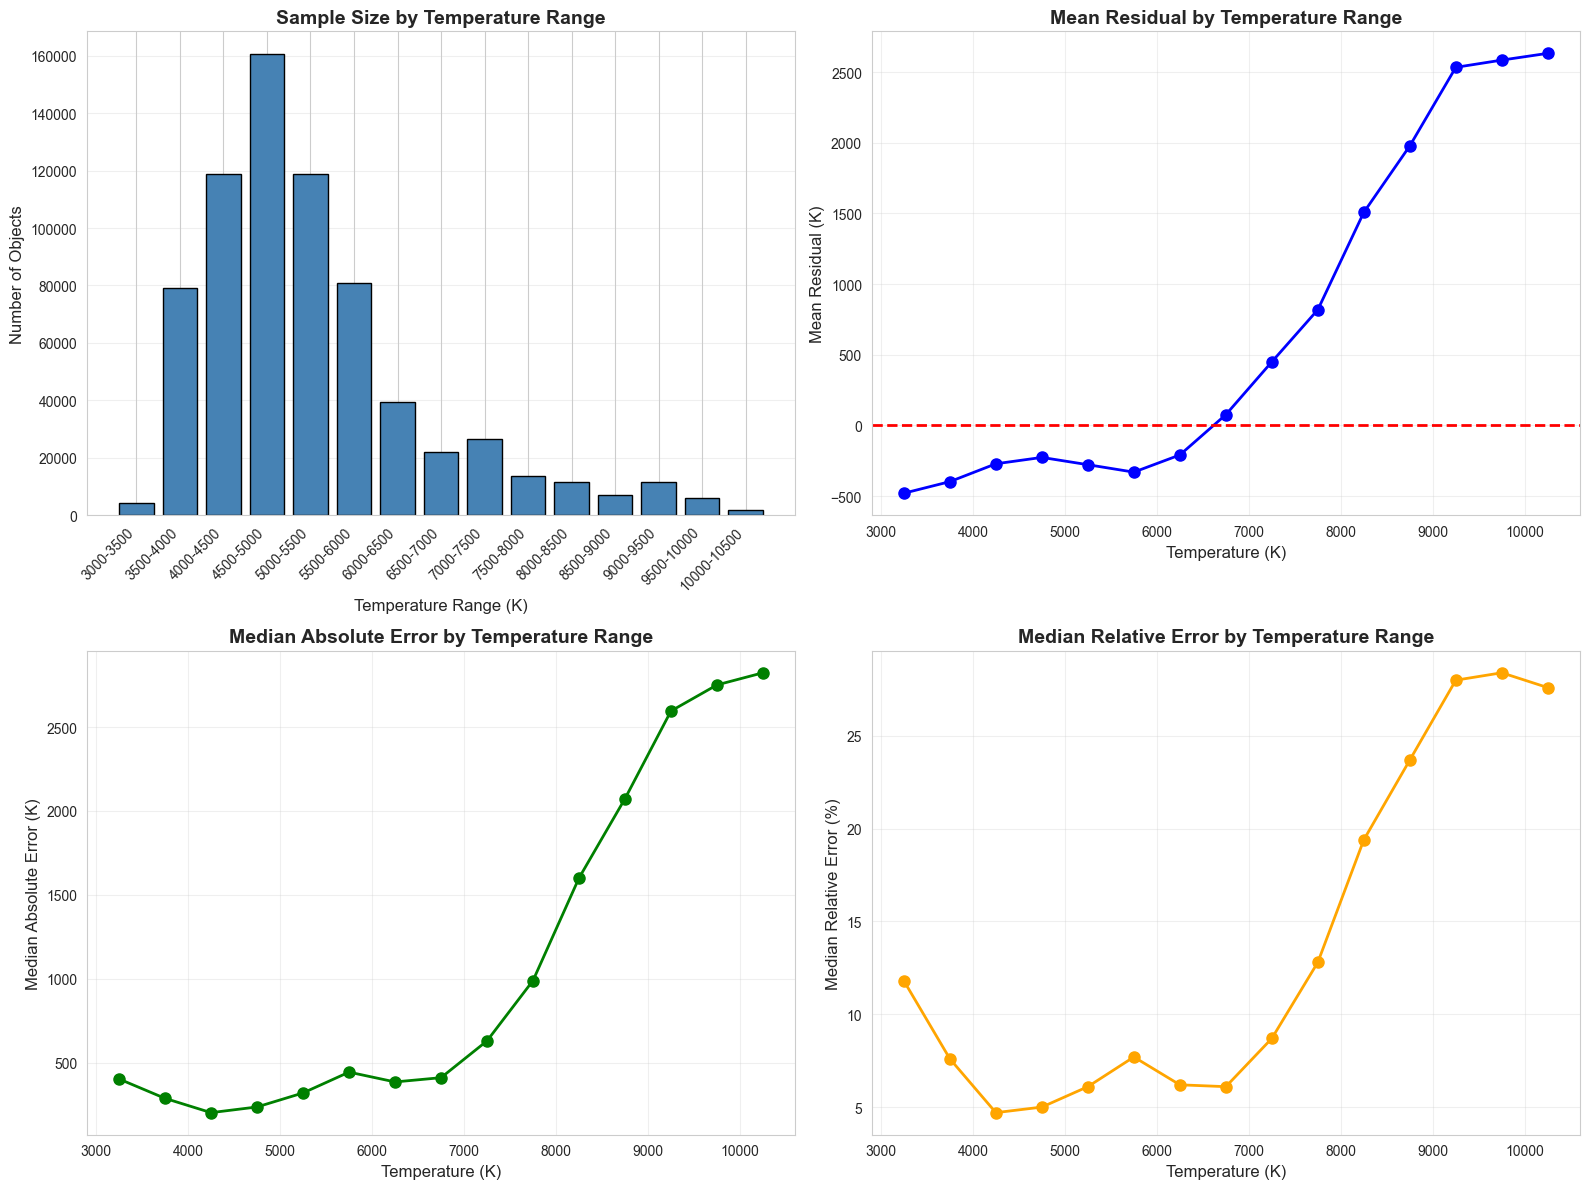


✓ Performance analysis by temperature range complete


In [9]:
# Define temperature bins
temp_bins = np.arange(3000, 11000, 500)
df_with_truth['temp_bin'] = pd.cut(df_with_truth['teff_gspphot'], bins=temp_bins)

# Calculate statistics per bin
bin_stats = df_with_truth.groupby('temp_bin').agg({
    'prediction_residual': ['count', 'mean', 'std', lambda x: np.median(np.abs(x))],
    'prediction_error_percent': ['mean', 'median']
}).round(1)

bin_stats.columns = ['Count', 'Mean Residual (K)', 'Std Residual (K)', 'Median |Residual| (K)', 
                     'Mean Error %', 'Median Error %']

print("\n" + "="*80)
print("MODEL PERFORMANCE BY TEMPERATURE RANGE")
print("="*80)
print(bin_stats.to_string())

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get bin centers for plotting
bin_centers = [(b.left + b.right) / 2 for b in bin_stats.index]

# 1. Count per bin
ax1 = axes[0, 0]
ax1.bar(range(len(bin_stats)), bin_stats['Count'], color='steelblue', edgecolor='black')
ax1.set_xlabel('Temperature Range (K)', fontsize=12)
ax1.set_ylabel('Number of Objects', fontsize=12)
ax1.set_title('Sample Size by Temperature Range', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(bin_stats)))
ax1.set_xticklabels([f'{int(b.left)}-{int(b.right)}' for b in bin_stats.index], 
                     rotation=45, ha='right')
ax1.grid(alpha=0.3, axis='y')

# 2. Mean residual per bin
ax2 = axes[0, 1]
ax2.plot(bin_centers, bin_stats['Mean Residual (K)'], 'o-', color='blue', linewidth=2, markersize=8)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Temperature (K)', fontsize=12)
ax2.set_ylabel('Mean Residual (K)', fontsize=12)
ax2.set_title('Mean Residual by Temperature Range', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

# 3. Median absolute error per bin
ax3 = axes[1, 0]
ax3.plot(bin_centers, bin_stats['Median |Residual| (K)'], 'o-', color='green', linewidth=2, markersize=8)
ax3.set_xlabel('Temperature (K)', fontsize=12)
ax3.set_ylabel('Median Absolute Error (K)', fontsize=12)
ax3.set_title('Median Absolute Error by Temperature Range', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

# 4. Median relative error per bin
ax4 = axes[1, 1]
ax4.plot(bin_centers, bin_stats['Median Error %'], 'o-', color='orange', linewidth=2, markersize=8)
ax4.set_xlabel('Temperature (K)', fontsize=12)
ax4.set_ylabel('Median Relative Error (%)', fontsize=12)
ax4.set_title('Median Relative Error by Temperature Range', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
save_figure(fig, 'basic_model_performance_by_temperature.png', subdir='validation')
plt.show()

print("\n✓ Performance analysis by temperature range complete")

## Summary Statistics

Final summary of the basic model validation results.

In [10]:
print("\n" + "="*80)
print("BASIC RANDOM FOREST MODEL - VALIDATION SUMMARY")
print("="*80)

print("\nMODEL INFO:")
print("  Model: rf_temperature_regressor_20251001_125556.pkl")
print("  Features: 5 (g_r_color, r_i_color, i_z_color, B_V_color, gPSFMag)")
print("  Feature Engineering: None (basic model)")

print("\nDATASET COVERAGE:")
print(f"  Total objects predicted: {len(df):,}")
print(f"  Objects with ground truth: {len(df_with_truth):,} ({100*len(df_with_truth)/len(df):.1f}%)")
print(f"  New predictions (no ground truth): {len(df_without_truth):,} ({100*len(df_without_truth)/len(df):.1f}%)")

print("\nMODEL PERFORMANCE (vs. Gaia GSP-Phot):")
mae = df_with_truth['prediction_residual'].abs().mean()
median_ae = df_with_truth['prediction_residual'].abs().median()
rmse = np.sqrt((df_with_truth['prediction_residual']**2).mean())
ss_res = (df_with_truth['prediction_residual']**2).sum()
ss_tot = ((df_with_truth['teff_gspphot'] - df_with_truth['teff_gspphot'].mean())**2).sum()
r2 = 1 - (ss_res / ss_tot)

print(f"  MAE: {mae:.1f} K")
print(f"  Median AE: {median_ae:.1f} K")
print(f"  RMSE: {rmse:.1f} K")
print(f"  R²: {r2:.3f}")
print(f"  Mean relative error: {df_with_truth['prediction_error_percent'].mean():.2f}%")
print(f"  Median relative error: {df_with_truth['prediction_error_percent'].median():.2f}%")

# Objects within error thresholds
within_5pct = (df_with_truth['prediction_error_percent'] <= 5).sum()
within_10pct = (df_with_truth['prediction_error_percent'] <= 10).sum()
within_20pct = (df_with_truth['prediction_error_percent'] <= 20).sum()

print("\nPREDICTION ACCURACY:")
print(f"  Within 5% error: {within_5pct:,} ({100*within_5pct/len(df_with_truth):.1f}%)")
print(f"  Within 10% error: {within_10pct:,} ({100*within_10pct/len(df_with_truth):.1f}%)")
print(f"  Within 20% error: {within_20pct:,} ({100*within_20pct/len(df_with_truth):.1f}%)")

print("\nTEMPERATURE STATISTICS:")
print("\n  Gaia GSP-Phot (ground truth):")
print(f"    Range: {df_with_truth['teff_gspphot'].min():.0f} - {df_with_truth['teff_gspphot'].max():.0f} K")
print(f"    Mean: {df_with_truth['teff_gspphot'].mean():.0f} K")
print(f"    Median: {df_with_truth['teff_gspphot'].median():.0f} K")
print(f"    Std: {df_with_truth['teff_gspphot'].std():.0f} K")

print("\n  Predicted (all objects):")
print(f"    Range: {df['teff_predicted'].min():.0f} - {df['teff_predicted'].max():.0f} K")
print(f"    Mean: {df['teff_predicted'].mean():.0f} K")
print(f"    Median: {df['teff_predicted'].median():.0f} K")
print(f"    Std: {df['teff_predicted'].std():.0f} K")

print("\n  New predictions (no ground truth):")
print(f"    Range: {df_without_truth['teff_predicted'].min():.0f} - {df_without_truth['teff_predicted'].max():.0f} K")
print(f"    Mean: {df_without_truth['teff_predicted'].mean():.0f} K")
print(f"    Median: {df_without_truth['teff_predicted'].median():.0f} K")
print(f"    Std: {df_without_truth['teff_predicted'].std():.0f} K")

print("\n" + "="*80)
print("✓ Basic model validation complete!")
print("="*80)


BASIC RANDOM FOREST MODEL - VALIDATION SUMMARY

MODEL INFO:
  Model: rf_temperature_regressor_20251001_125556.pkl
  Features: 5 (g_r_color, r_i_color, i_z_color, B_V_color, gPSFMag)
  Feature Engineering: None (basic model)

DATASET COVERAGE:
  Total objects predicted: 1,123,615
  Objects with ground truth: 705,998 (62.8%)
  New predictions (no ground truth): 417,617 (37.2%)

MODEL PERFORMANCE (vs. Gaia GSP-Phot):
  MAE: 553.7 K
  Median AE: 325.9 K
  RMSE: 906.8 K
  R²: 0.594
  Mean relative error: 9.58%
  Median relative error: 6.63%

PREDICTION ACCURACY:
  Within 5% error: 286,316 (40.6%)
  Within 10% error: 458,476 (64.9%)
  Within 20% error: 617,761 (87.5%)

TEMPERATURE STATISTICS:

  Gaia GSP-Phot (ground truth):
    Range: 2737 - 31144 K
    Mean: 5317 K
    Median: 4967 K
    Std: 1423 K

  Predicted (all objects):
    Range: 3183 - 15597 K
    Mean: 5009 K
    Median: 4742 K
    Std: 1084 K

  New predictions (no ground truth):
    Range: 3186 - 15332 K
    Mean: 4382 K
    M